In [1]:
pwd

'/gpfs/data/arsoyd01lab/machlm03/Segmentation/MedSAM2/oai_utils'

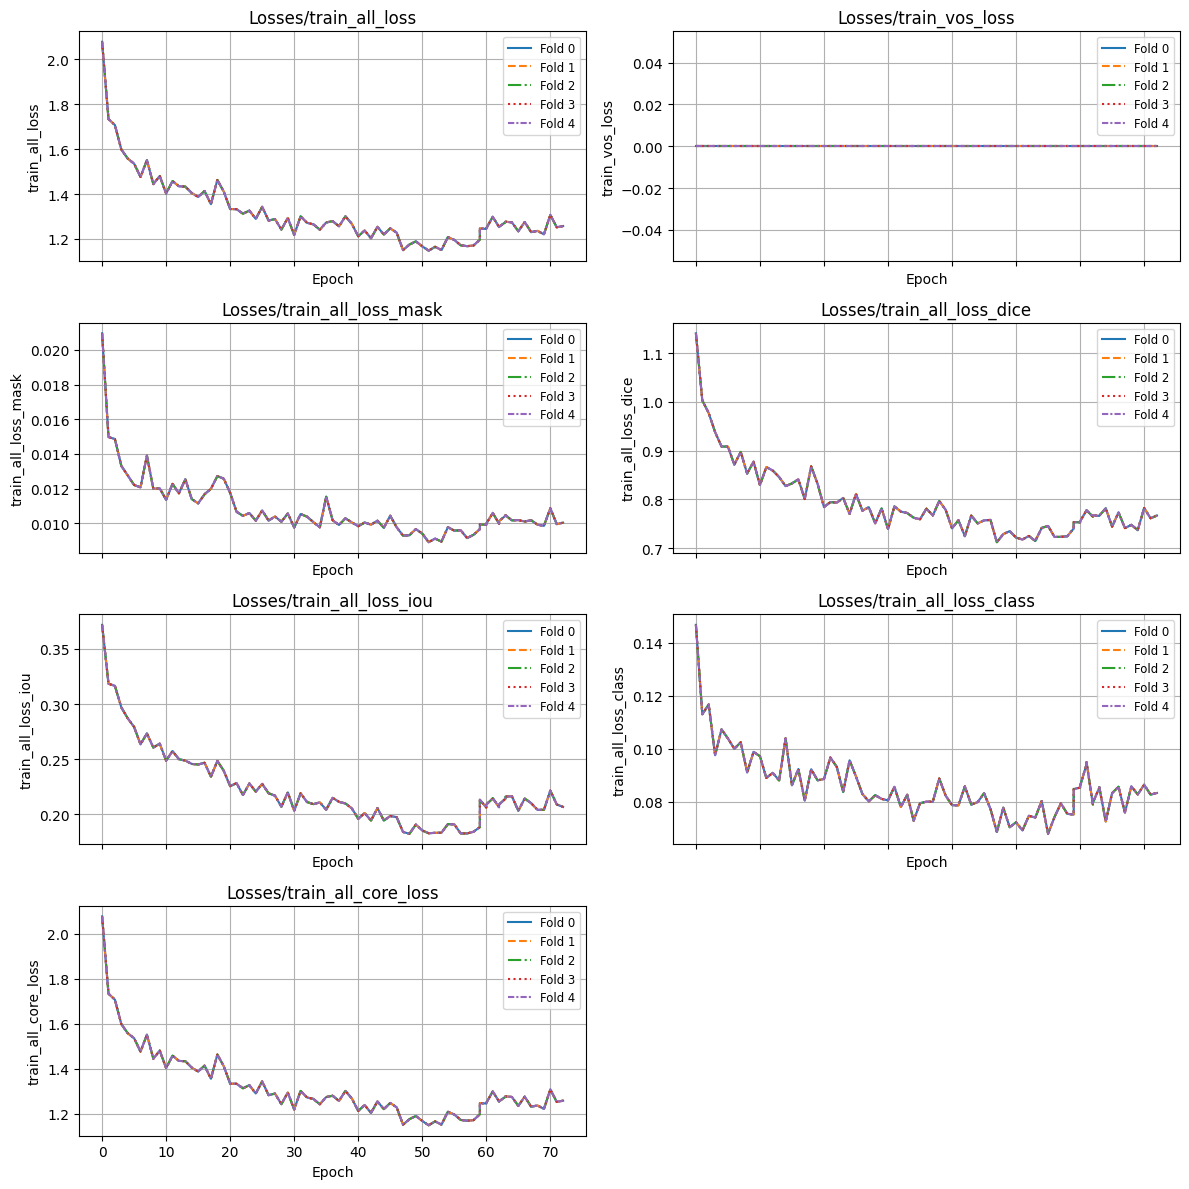

In [9]:
import json
import matplotlib.pyplot as plt
import os
import math

base_dir = "/gpfs/home/machlm03/Segmentation/MedSAM2/MSAM2.4/"

num_folds = 5

def plot(file):
    # Get loss keys from first fold first line
    first_log_path = os.path.join(base_dir, "logs", file)
    first_log_path = os.path.join(base_dir, "logs", file)

    with open(first_log_path, "r") as f:
        first_line = f.readline()
    record = json.loads(first_line)
    
    # Filter to loss keys only (exclude metadata keys)
    loss_keys = [k for k in record.keys() if not k.startswith('Trainer/')]
    
    # Determine subplot grid size
    num_losses = len(loss_keys)
    cols = 2  # number of columns in subplot grid (you can change as you prefer)
    rows = math.ceil(num_losses / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 3), sharex=True)
    axes = axes.flatten()
    
    line_styles = ['-', '--', '-.', ':', (0, (3,1,1,1)), (0, (5,1))]
    colors = plt.cm.tab10(range(num_folds))  # one color per fold
    
    for loss_idx, loss_key in enumerate(loss_keys):
        ax = axes[loss_idx]
        for fold in range(num_folds):
            fold_dir = os.path.join(base_dir, "logs")
            log_file_path = os.path.join(fold_dir, file)
            
            if not os.path.exists(log_file_path):
                print(f"Log file missing for fold {fold}, skipping.")
                continue
            
            epochs = []
            values = []
            with open(log_file_path, 'r') as f:
                for line in f:
                    if line.strip():
                        rec = json.loads(line)
                        epoch = rec.get("Trainer/epoch")
                        val = rec.get(loss_key)
                        if epoch is not None and val is not None:
                            epochs.append(epoch)
                            values.append(val)
            
            if not epochs:
                continue
            
            # Sort by epoch
            epochs, values = zip(*sorted(zip(epochs, values)))
            ax.plot(
                epochs, values,
                label=f"Fold {fold}",
                color=colors[fold],
                linestyle=line_styles[fold % len(line_styles)],
                alpha=1
            )
        
        ax.set_title(loss_key)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(loss_key.split('/')[1])
        ax.grid(True)
        ax.legend(fontsize='small')
    
    # Hide unused subplots if number of losses is odd
    for i in range(num_losses, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

plot("train_stats.json")

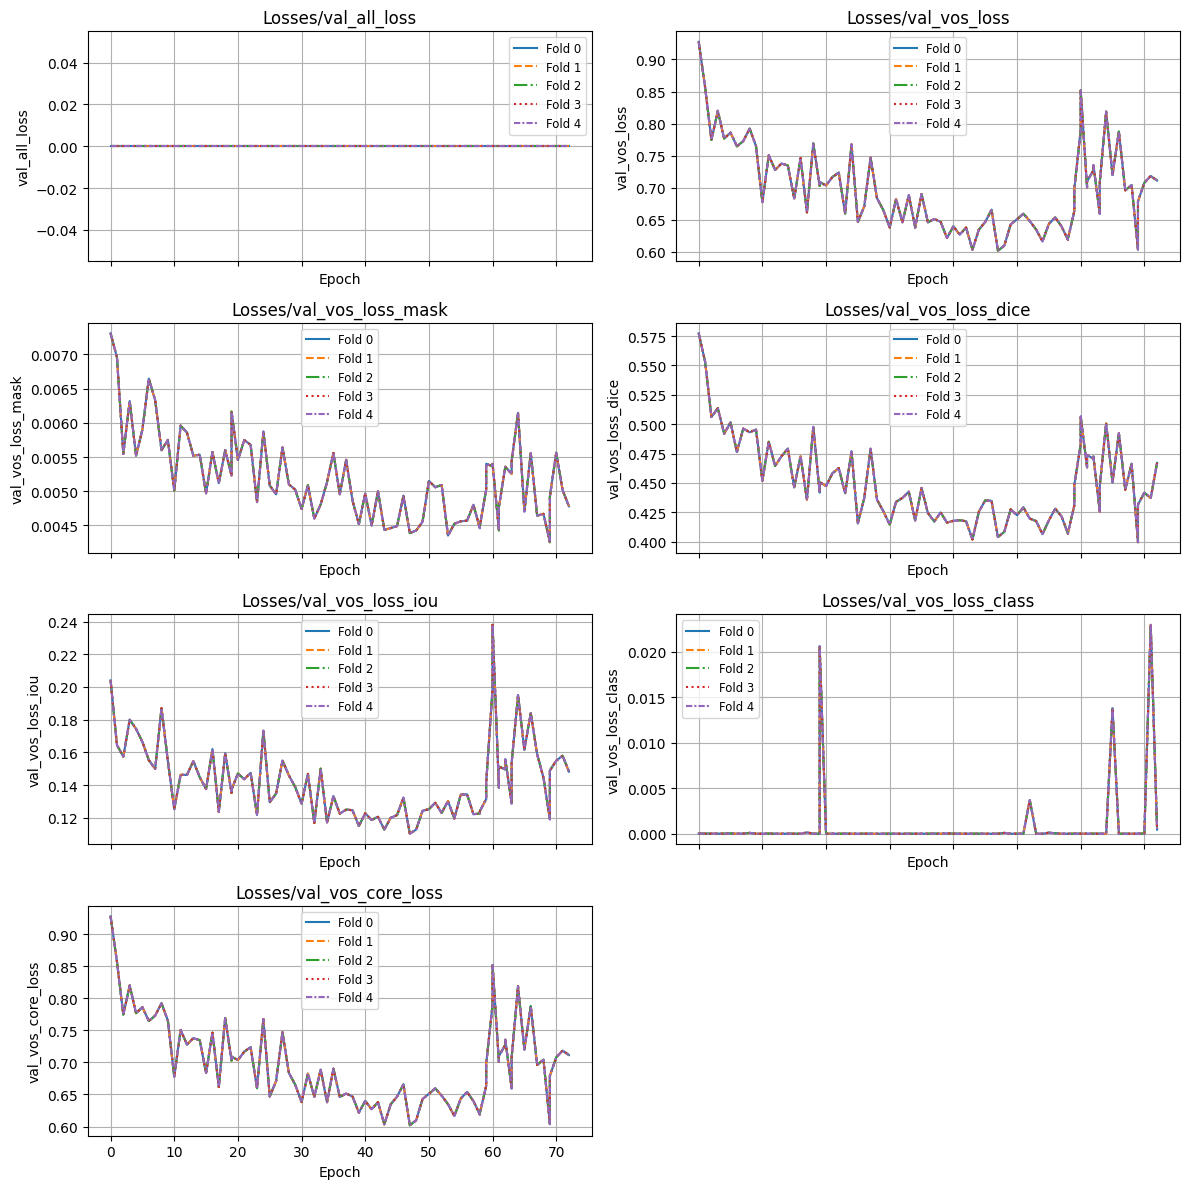

In [7]:
plot("val_stats.json")

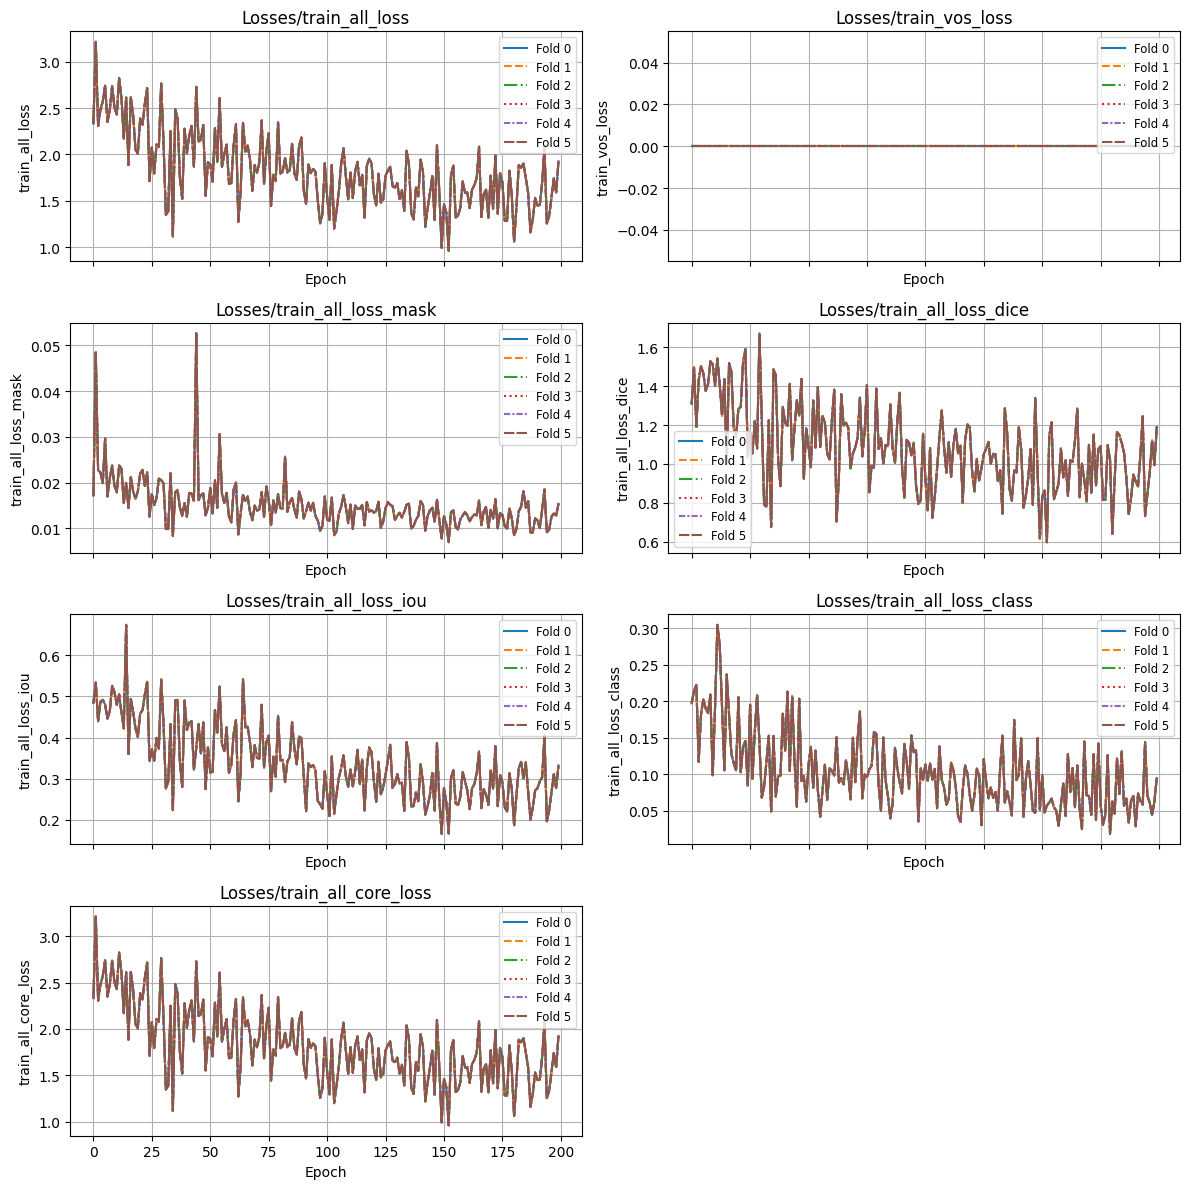

In [4]:
import json
import matplotlib.pyplot as plt
import os
import math

base_dir = "/gpfs/home/machlm03/Segmentation/MedSAM2/MSAM_IWOAI/"

num_folds = 6

def plot(file):
    # Get loss keys from first fold first line
    first_log_path = os.path.join(base_dir, "logs", file)
    # first_log_path = os.path.join(base_dir, "logs", file)

    with open(first_log_path, "r") as f:
        first_line = f.readline()
    record = json.loads(first_line)
    
    # Filter to loss keys only (exclude metadata keys)
    loss_keys = [k for k in record.keys() if not k.startswith('Trainer/')]
    
    # Determine subplot grid size
    num_losses = len(loss_keys)
    cols = 2  # number of columns in subplot grid (you can change as you prefer)
    rows = math.ceil(num_losses / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 3), sharex=True)
    axes = axes.flatten()
    
    line_styles = ['-', '--', '-.', ':', (0, (3,1,1,1)), (0, (5,1))]
    colors = plt.cm.tab10(range(num_folds))  # one color per fold
    
    for loss_idx, loss_key in enumerate(loss_keys):
        ax = axes[loss_idx]
        for fold in range(num_folds):
            fold_dir = os.path.join(base_dir, "logs")
            log_file_path = os.path.join(fold_dir, file)
            
            if not os.path.exists(log_file_path):
                # print(f"Log file missing for fold {fold}, skipping.")
                continue
            
            epochs = []
            values = []
            with open(log_file_path, 'r') as f:
                for line in f:
                    if line.strip():
                        rec = json.loads(line)
                        epoch = rec.get("Trainer/epoch")
                        val = rec.get(loss_key)
                        if epoch is not None and val is not None:
                            epochs.append(epoch)
                            values.append(val)
            
            if not epochs:
                continue
            
            # Sort by epoch
            epochs, values = zip(*sorted(zip(epochs, values)))
            ax.plot(
                epochs, values,
                label=f"Fold {fold}",
                color=colors[fold],
                linestyle=line_styles[fold % len(line_styles)],
                alpha=1
            )
        
        ax.set_title(loss_key)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(loss_key.split('/')[1])
        ax.grid(True)
        ax.legend(fontsize='small')
    
    # Hide unused subplots if number of losses is odd
    for i in range(num_losses, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

plot("train_stats.json")

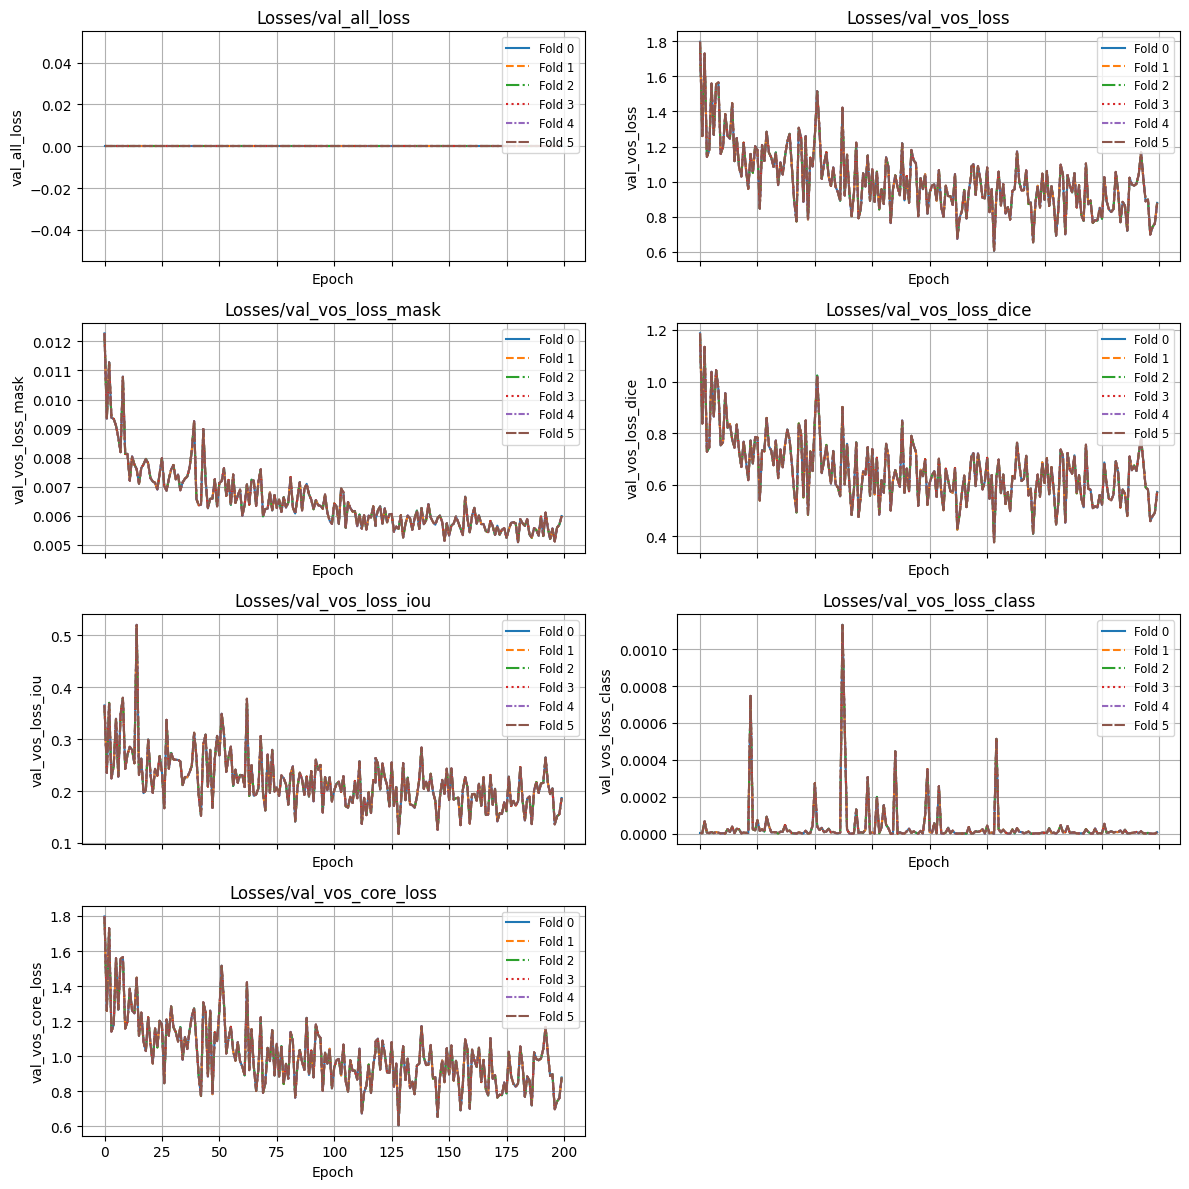

In [19]:
plot("val_stats.json")

In [ ]:
/gpfs/home/machlm03/Segmentation/MedSAM2/MSAM_IWOAI/5/checkpoints/checkpoint_30.pt
/gpfs/home/machlm03/Segmentation/IWOAI_Segmentation_Challenge/MSAM_IWOAI_trained

In [13]:
# partition function
def partition(arr, low, high):
    
    # choose the pivot
    pivot = arr[high]
    
    # index of smaller element and indicates 
    # the right position of pivot found so far
    i = low - 1
    
    # traverse arr[low..high] and move all smaller
    # elements to the left side. Elements from low to 
    # i are smaller after every iteration
    for j in range(low, high):
        if arr[j] < pivot:
            i += 1
            swap(arr, i, j)
    
    # move pivot after smaller elements and
    # return its position
    swap(arr, i + 1, high)
    print(arr)
    print(i+1)
    return i + 1

# swap function
def swap(arr, i, j):
    arr[i], arr[j] = arr[j], arr[i]

# the QuickSort function implementation
def quickSort(arr, low, high):
    if low < high:
        
        # pi is the partition return index of pivot
        pi = partition(arr, low, high)
        
        # recursion calls for smaller elements
        # and greater or equals elements
        quickSort(arr, low, pi - 1)
        quickSort(arr, pi + 1, high)

if __name__ == "__main__":
    arr = [10, 7, 8, 9, 1, 5]
    n = len(arr)

    quickSort(arr, 0, n - 1)
    
    for val in arr:
        print(val, end=" ")

[1, 5, 8, 9, 10, 7]
1
[1, 5, 7, 9, 10, 8]
2
[1, 5, 7, 8, 10, 9]
3
[1, 5, 7, 8, 9, 10]
4
1 5 7 8 9 10 